In [2]:
import pandas as pd 
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [8]:
df["Gender"] =df["Gender"].map({"Male":0,"Female":1})

In [9]:
from sklearn.preprocessing import StandardScaler
X= df[["Annual Income (k$)","Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.cluster import KMeans
inertias =[]
for k in range (2,11):
    km = KMeans(n_clusters=k,random_state = 42,n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

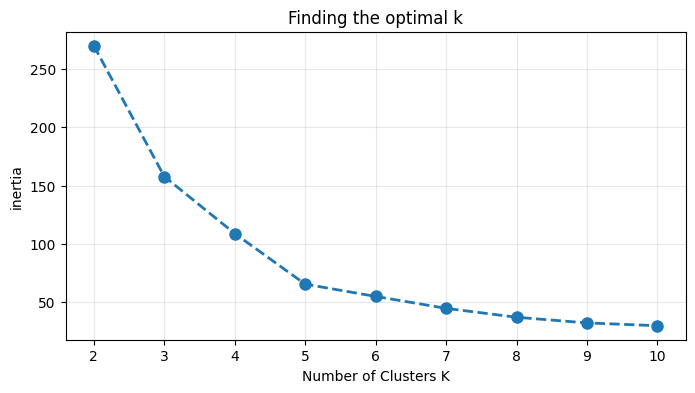

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(range(2,11),inertias,"--o",linewidth =2,markersize=8)
plt.xlabel("Number of Clusters K")
plt.ylabel("inertia")
plt.title("Finding the optimal k")
plt.xticks(range(2,11))
plt.grid(alpha=0.3)
plt.show()

In [12]:
km_final = KMeans(n_clusters=5,random_state=42,n_init=10)
df["cluster"]= km_final.fit_predict(X_scaled)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4
...,...,...,...,...,...,...
195,196,1,35,120,79,1
196,197,1,45,126,28,3
197,198,0,32,126,74,1
198,199,0,32,137,18,3


In [13]:
profile = df.groupby("cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean().round(0)
profile["count"]=df["cluster"].value_counts().sort_index()
profile

,Annual Income (k$),Spending Score (1-100),count
cluster,,,
0,55.0,50.0,81
1,87.0,82.0,39
2,26.0,79.0,22
3,88.0,17.0,35
4,26.0,21.0,23


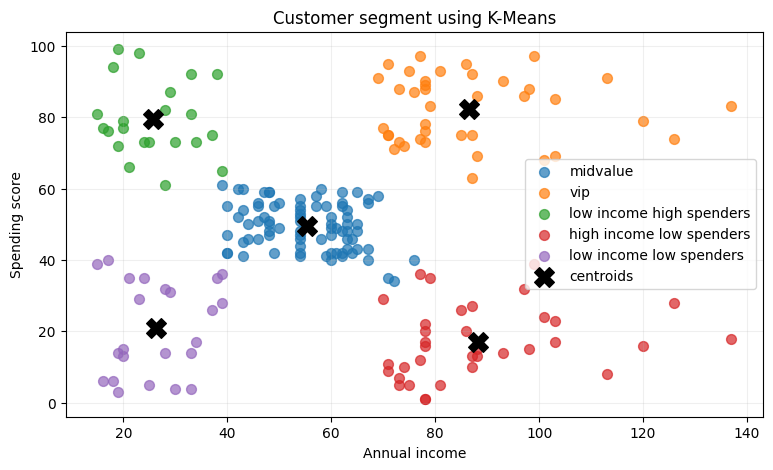

In [14]:
labels =["midvalue","vip","low income high spenders","high income low spenders","low income low spenders"]
plt.figure(figsize=(9,5))
for c in range(5):
    mask = df["cluster"] == c
    plt.scatter(
        df[mask]["Annual Income (k$)"],
        df[mask]["Spending Score (1-100)"],
        label = labels[c],
        alpha = 0.7,
        s = 50

    )
centroids_orig= scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(centroids_orig[:,0],centroids_orig[:,1],
s=200,marker ="X",c ="black",zorder=5,label="centroids")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.title("Customer segment using K-Means")
plt.legend()
plt.grid(alpha = 0.2)
plt.show()

In [15]:
import numpy as np 
sub_ids = np.random.choice(len(X_scaled),50,replace=False)
X_sub =X_scaled[sub_ids]

In [16]:
from scipy.cluster.hierarchy import dendrogram,linkage
z = linkage(X_sub,method="ward")

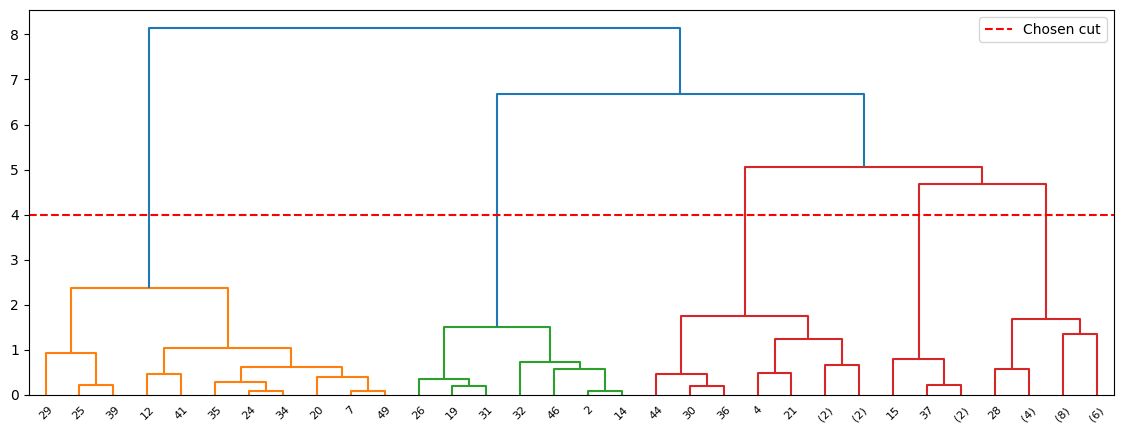

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
dendrogram(z,truncate_mode="level",p=5)
plt.axhline(
    y=4,                    
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Chosen cut"
)
plt.legend()
plt.show()


In [18]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5,linkage ="ward")
df["hc_cluster"]=hc.fit_predict(X_scaled)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,hc_cluster
0,1,0,19,15,39,4,4
1,2,0,21,15,81,2,3
2,3,1,20,16,6,4,4
3,4,1,23,16,77,2,3
4,5,1,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,1,35,120,79,1,1
196,197,1,45,126,28,3,0
197,198,0,32,126,74,1,1
198,199,0,32,137,18,3,0


In [19]:
print(df.groupby("cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean().round(0))

         Annual Income (k$)  Spending Score (1-100)
cluster                                            
0                      55.0                    50.0
1                      87.0                    82.0
2                      26.0                    79.0
3                      88.0                    17.0
4                      26.0                    21.0


In [20]:
print(df.groupby("hc_cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean().round(0))

            Annual Income (k$)  Spending Score (1-100)
hc_cluster                                            
0                         89.0                    16.0
1                         87.0                    82.0
2                         56.0                    49.0
3                         25.0                    80.0
4                         26.0                    21.0


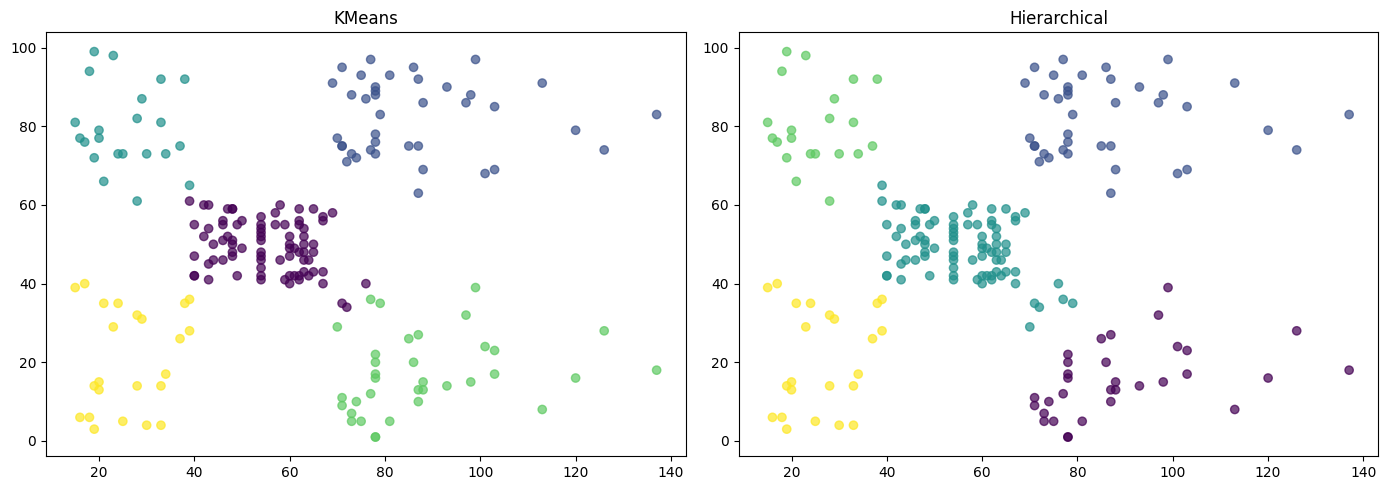

In [22]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c = df["cluster"],
    alpha = 0.7
)
axes[0].set_title("KMeans")
axes[1].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c = df["hc_cluster"],
    alpha = 0.7
)
axes[1].set_title("Hierarchical")

plt.tight_layout()
plt.show()
